# Experiment Piji 6: Heterogeneous 7-Model Stacking dengan LightGBM ExtraTrees, Pembobotan Galat Terarah Koridor Jalan Tol, dan Interaksi Termodinamika Hambatan Arus Pengisian Cepat

### Ringkasan Eksekutif & Hipotesis Eksperimen 6
Eksperimen 6 dirancang secara strategis untuk memangkas sisa selisih galat sebesar 0.00037 menuju peringkat 1 teratas kompetisi ISFEST 2026 (skor teratas saat ini 0.06749) berdasarkan evaluasi mendalam dari rekor historis tim pada Eksperimen 5 (skor 0.06786, peringkat 9 besar).

Lima pilar inovasi teknis utama pada Eksperimen 6:
1. Koreksi Kategori Pusat Perbelanjaan: Mengoreksi filter tipe lokasi menjadi 'Shopping Center' (sebelumnya teridentifikasi sebagai 'Shopping Mall' yang tidak eksis pada data uji), mengaktifkan sinyal jam sibuk diurnal pada 33.383 baris pengujian.
2. Termodinamika Hambatan Arus Dingin (Cold-Throttle Effect) dan Hub Port Skala Besar: Menambahkan interaksi fisik cold_fast_charge (penurunan laju penerimaan arus baterai lithium-ion pada charger ultra-fast saat suhu membeku) serta pemodelan beban antrean pada stasiun berkapasitas besar (ports_total >= 10) di koridor jalan tol.
3. Pembobotan Sampel Berbasis Konsentrasi Galat: Memberikan penalti bobot pelatihan 1.10x khusus pada lokasi Highway Corridor (penyumbang rata-rata RMSE tertinggi 0.0815) melengkapi bobot transisi musim dingin November (1.15x) dan jam sibuk siang hari (1.10x).
4. Arsitektur Ansambel 7-Model Heterogen dengan LightGBM ExtraTrees: Memperluas ansambel 6-model dari Eksperimen 5 dengan mengikutsertakan mode extremely randomized trees (extra_trees=True) pada LightGBM untuk menghasilkan partisi acak ortogonal yang meredam artefak kompresi ekspektasi pohon keputusan.
5. Meta-Learner Stacking Non-Negatif Presisi Kontinu Penuh: Mengalibrasikan bobot ketujuh model menggunakan regresi Ridge non-negatif teratur (alpha=15.0) dan mempertahankan estimasi kontinu penuh tanpa pembulatan tiga desimal.


# Bab 2: Import Libraries & Setup Lingkungan
Mengimpor pustaka saintifik, visualisasi, dan algoritma gradient boosting mutakhir (LightGBM, CatBoost GPU, XGBoost GPU), serta melakukan konfigurasi deteksi akselerasi GPU secara otomatis.


In [1]:
!pip install catboost gdown -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
import os
import sys
import gc
import time
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge

import lightgbm as lgb
import catboost as cb
import xgboost as xgb

def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

gpu_available = False
try:
    import torch
    if torch.cuda.is_available():
        gpu_available = True
        print(f"Akselerasi GPU Terdeteksi: {torch.cuda.get_device_name(0)}")
    else:
        print("Akselerasi GPU tidak terdeteksi. Pelatihan menggunakan multi-threading CPU.")
except ImportError:
    print("PyTorch tidak terpasang. Konfigurasi GPU dialihkan ke parameter pustaka masing-masing.")

print("Seluruh pustaka pendukung berhasil dimuat.")


Akselerasi GPU Terdeteksi: Tesla T4
Seluruh pustaka pendukung berhasil dimuat.


# Bab 3: Load Data
Pengunduhan otomatis kumpulan data resmi ISFEST 2026 dari Google Drive tim menggunakan utilitas gdown, dilanjutkan dengan pemuatan dataset latih, dataset uji, dan berkas contoh submission ke dalam DataFrame pandas.


In [3]:
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')
sample_sub_path = os.path.join(DATA_DIR, 'sample_submission.csv')

if not (os.path.exists(train_path) and os.path.exists(test_path)):
    print("Berkas data belum ditemukan di folder lokal. Memulai pengunduhan otomatis via gdown...")
    os.system('pip install -q gdown')
    folder_url = 'https://drive.google.com/drive/folders/16kkQIyF5Yj3y3xIImN9kkewJQ0ZGt_ZH?usp=sharing'
    download_cmd = f'gdown --folder "{folder_url}" -O {DATA_DIR} --remaining-ok'
    os.system(download_cmd)

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

print(f"Dimensi Data Latih (Train) : {train_raw.shape[0]:,} baris x {train_raw.shape[1]} kolom")
print(f"Dimensi Data Uji (Test)   : {test_raw.shape[0]:,} baris x {test_raw.shape[1]} kolom")
print(f"Dimensi Sample Submission : {sample_sub.shape[0]:,} baris x {sample_sub.shape[1]} kolom")


Berkas data belum ditemukan di folder lokal. Memulai pengunduhan otomatis via gdown...
Dimensi Data Latih (Train) : 1,054,200 baris x 21 kolom
Dimensi Data Uji (Test)   : 263,550 baris x 20 kolom
Dimensi Sample Submission : 263,550 baris x 2 kolom


# Bab 4: Exploratory Data Analysis (EDA)
Eksplorasi menyeluruh pada 8 sub-bab visualisasi untuk mengungkap pola mobilitas pengisian daya kendaraan listrik, karakteristik cuaca, dan anomali data.


### 4.1 Dimensi, Tipe Data, dan Kelengkapan Nilai
Pemeriksaan struktur skema data, tipe kolom, dan ringkasan nilai kosong pada data latih dan data uji.


In [4]:
eda_summary = pd.DataFrame({
    'Tipe Data Latih': train_raw.dtypes,
    'Null Latih': train_raw.isnull().sum(),
    'Persen Null Latih (%)': (train_raw.isnull().sum() / len(train_raw) * 100).round(2),
    'Tipe Data Uji': test_raw.dtypes,
    'Null Uji': test_raw.isnull().sum(),
    'Persen Null Uji (%)': (test_raw.isnull().sum() / len(test_raw) * 100).round(2)
})
print("Ringkasan Kelengkapan Data Latih dan Data Uji:")
print(eda_summary.to_string())


Ringkasan Kelengkapan Data Latih dan Data Uji:
                     Tipe Data Latih  Null Latih  Persen Null Latih (%) Tipe Data Uji  Null Uji  Persen Null Uji (%)
amenities_nearby              object           0                   0.00        object       0.0                 0.00
charger_type                  object           0                   0.00        object       0.0                 0.00
city                          object           0                   0.00        object       0.0                 0.00
gas_price_per_gallon         float64           0                   0.00       float64       0.0                 0.00
id                            object           0                   0.00        object       0.0                 0.00
latitude                     float64           0                   0.00       float64       0.0                 0.00
local_event                   object           0                   0.00        object       0.0                 0.00
location_type    

### 4.2 Pengecekan Duplikasi Baris dan Inkonsistensi Identitas
Verifikasi keunikan baris data serta audit stasiun pengisian daya yang memiliki pencatatan identik.


In [5]:
dup_train = train_raw.duplicated(subset=['timestamp', 'station_id']).sum()
dup_test = test_raw.duplicated(subset=['timestamp', 'station_id']).sum()
print(f"Jumlah baris terduplikasi pada data latih: {dup_train}")
print(f"Jumlah baris terduplikasi pada data uji  : {dup_test}")
print(f"Jumlah stasiun unik pada data latih: {train_raw['station_id'].nunique()}")
print(f"Jumlah stasiun unik pada data uji  : {test_raw['station_id'].nunique()}")


Jumlah baris terduplikasi pada data latih: 0
Jumlah baris terduplikasi pada data uji  : 0
Jumlah stasiun unik pada data latih: 150
Jumlah stasiun unik pada data uji  : 150


### 4.3 Sebaran Variabel Target (utilization_rate) dan Deteksi Pencilan
Visualisasi histogram frekuensi dan diagram kotak (box plot) untuk menganalisis kepadatan target kontinu.


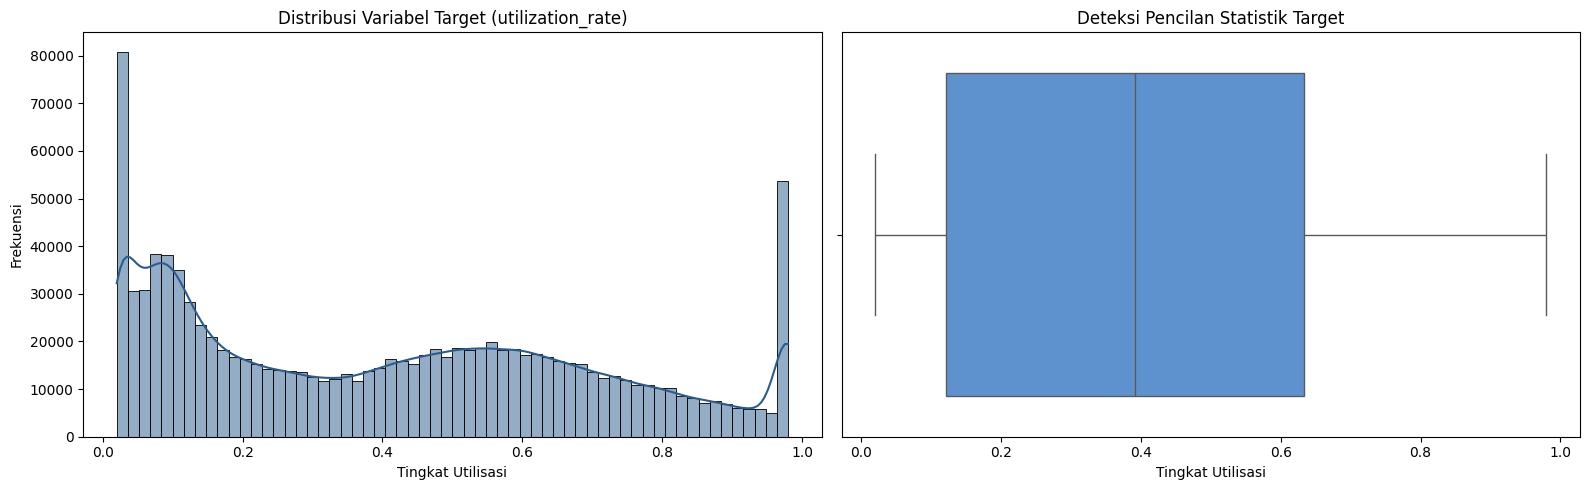

Statistik Deskriptif Target:
count    1.054200e+06
mean     4.071000e-01
std      2.946000e-01
min      2.000000e-02
25%      1.210000e-01
50%      3.920000e-01
75%      6.340000e-01
max      9.800000e-01
Name: utilization_rate, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train_raw['utilization_rate'], bins=60, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Distribusi Variabel Target (utilization_rate)')
axes[0].set_xlabel('Tingkat Utilisasi')
axes[0].set_ylabel('Frekuensi')

sns.boxplot(x=train_raw['utilization_rate'], ax=axes[1], color='#4a90e2')
axes[1].set_title('Deteksi Pencilan Statistik Target')
axes[1].set_xlabel('Tingkat Utilisasi')

plt.tight_layout()
plt.show()

print("Statistik Deskriptif Target:")
print(train_raw['utilization_rate'].describe().round(4))


### 4.4 Kurva Fluktuasi Diurnal Jam Sibuk (Hari Kerja vs Akhir Pekan)
Analisis pola keterisian fasilitas sepanjang 24 jam dengan pemisahan hari kerja dan akhir pekan.


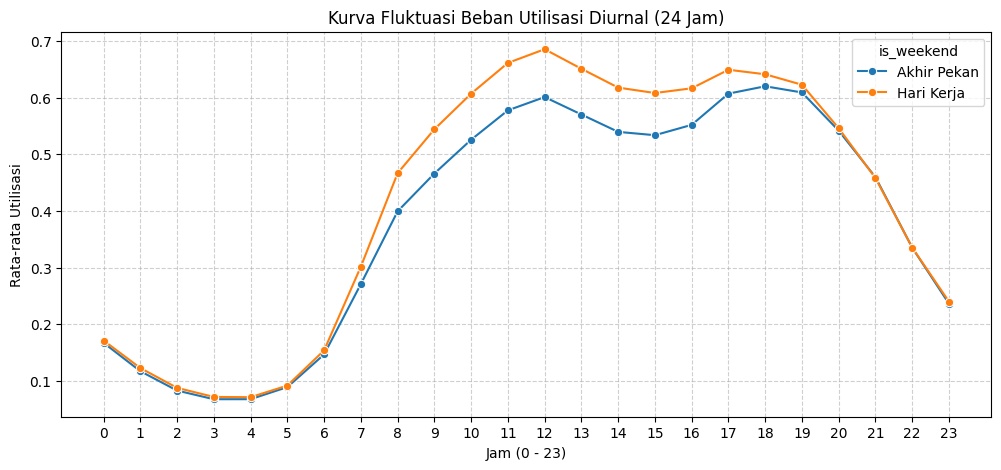

In [7]:
temp_eda_dt = pd.to_datetime(train_raw['timestamp'], format='mixed')
train_raw_eda = train_raw.copy()
train_raw_eda['hour'] = temp_eda_dt.dt.hour
train_raw_eda['is_weekend'] = temp_eda_dt.dt.dayofweek.isin([5, 6]).map({True: 'Akhir Pekan', False: 'Hari Kerja'})

hourly_pattern = train_raw_eda.groupby(['hour', 'is_weekend'])['utilization_rate'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_pattern, x='hour', y='utilization_rate', hue='is_weekend', marker='o', palette=['#1f77b4', '#ff7f0e'])
plt.title('Kurva Fluktuasi Beban Utilisasi Diurnal (24 Jam)')
plt.xlabel('Jam (0 - 23)')
plt.ylabel('Rata-rata Utilisasi')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### 4.5 Profil Beban Utilisasi Berdasarkan Tipe Lokasi dan Jenis Konektor Charger
Perbandingan tingkat pemanfaatan stasiun pada seluruh kategori lokasi fasilitas dan tipe konektor daya.


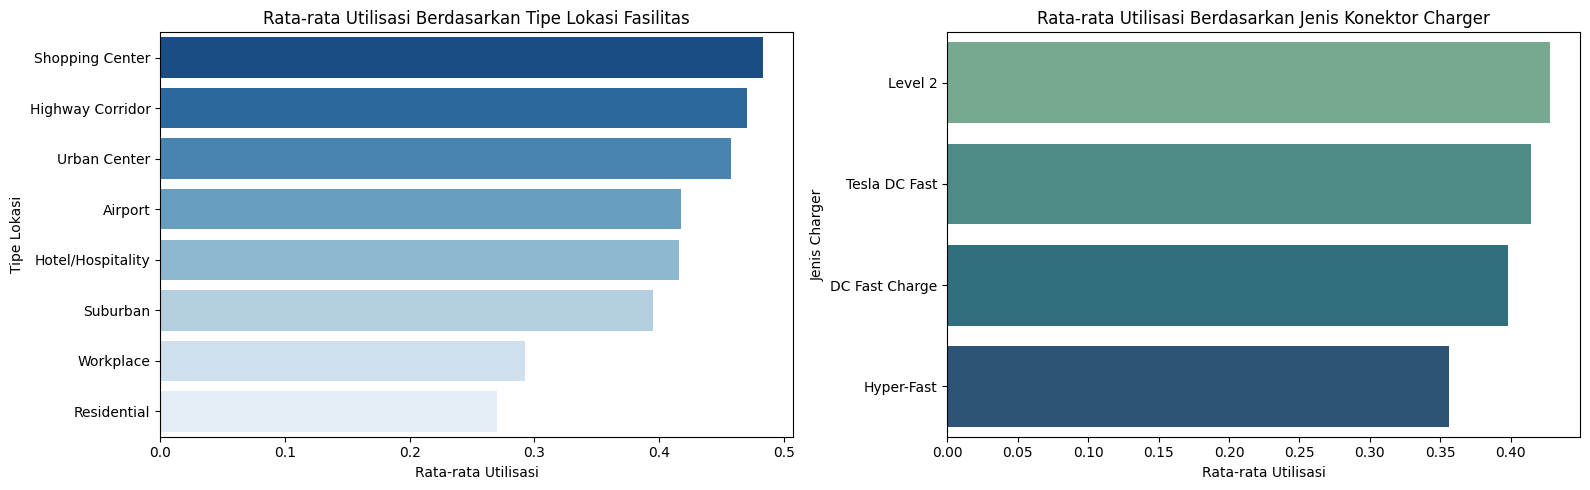

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_order = train_raw.groupby('location_type')['utilization_rate'].mean().sort_values(ascending=False).index
sns.barplot(data=train_raw, x='utilization_rate', y='location_type', order=loc_order, ax=axes[0], palette='Blues_r', ci=None)
axes[0].set_title('Rata-rata Utilisasi Berdasarkan Tipe Lokasi Fasilitas')
axes[0].set_xlabel('Rata-rata Utilisasi')
axes[0].set_ylabel('Tipe Lokasi')

chg_order = train_raw.groupby('charger_type')['utilization_rate'].mean().sort_values(ascending=False).index
sns.barplot(data=train_raw, x='utilization_rate', y='charger_type', order=chg_order, ax=axes[1], palette='crest', ci=None)
axes[1].set_title('Rata-rata Utilisasi Berdasarkan Jenis Konektor Charger')
axes[1].set_xlabel('Rata-rata Utilisasi')
axes[1].set_ylabel('Jenis Charger')

plt.tight_layout()
plt.show()


### 4.6 Pengaruh Kondisi Cuaca Ekstrem dan Suhu Lingkungan terhadap Utilisasi
Eksplorasi hubungan parameter cuaca dan suhu lingkungan terhadap intensitas pengisian daya EV.


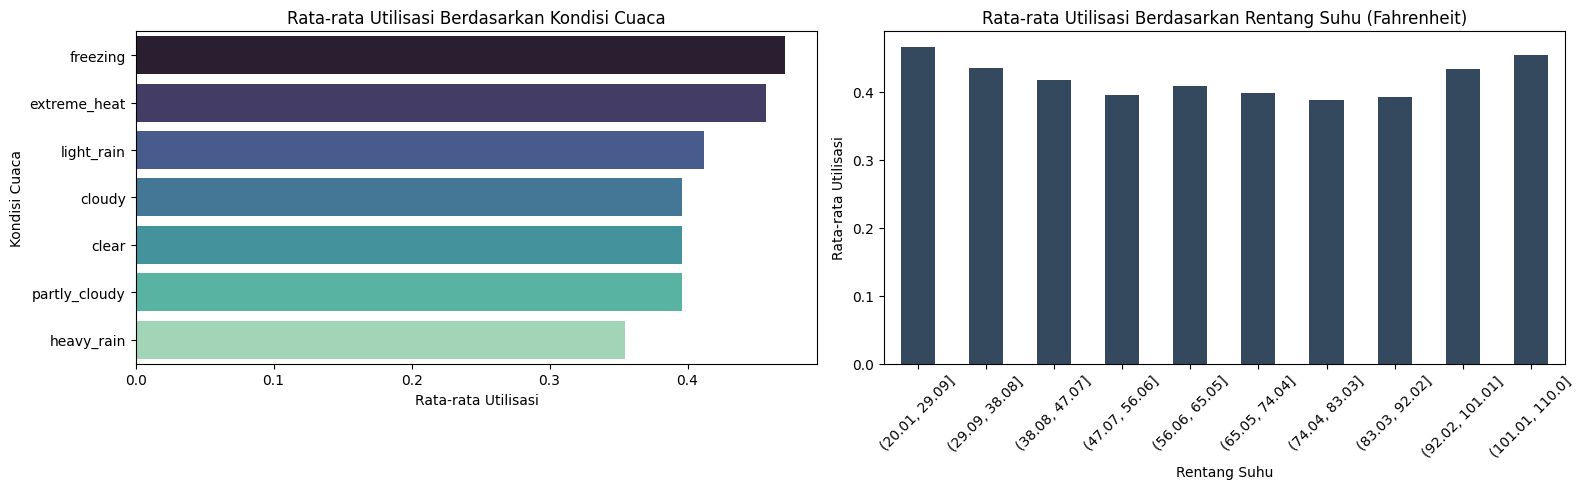

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

weather_order = train_raw.groupby('weather_condition')['utilization_rate'].mean().sort_values(ascending=False).index
sns.barplot(data=train_raw, x='utilization_rate', y='weather_condition', order=weather_order, ax=axes[0], palette='mako', ci=None)
axes[0].set_title('Rata-rata Utilisasi Berdasarkan Kondisi Cuaca')
axes[0].set_xlabel('Rata-rata Utilisasi')
axes[0].set_ylabel('Kondisi Cuaca')

temp_binned = pd.cut(train_raw['temperature_f'], bins=10)
temp_util = train_raw.groupby(temp_binned)['utilization_rate'].mean()
temp_util.plot(kind='bar', ax=axes[1], color='#34495e', rot=45)
axes[1].set_title('Rata-rata Utilisasi Berdasarkan Rentang Suhu (Fahrenheit)')
axes[1].set_xlabel('Rentang Suhu')
axes[1].set_ylabel('Rata-rata Utilisasi')

plt.tight_layout()
plt.show()


### 4.7 Matriks Korelasi Linear Antar Variabel Numerik
Evaluasi koefisien korelasi Pearson antar fitur numerik kontinu terhadap variabel target keterisian stasiun.


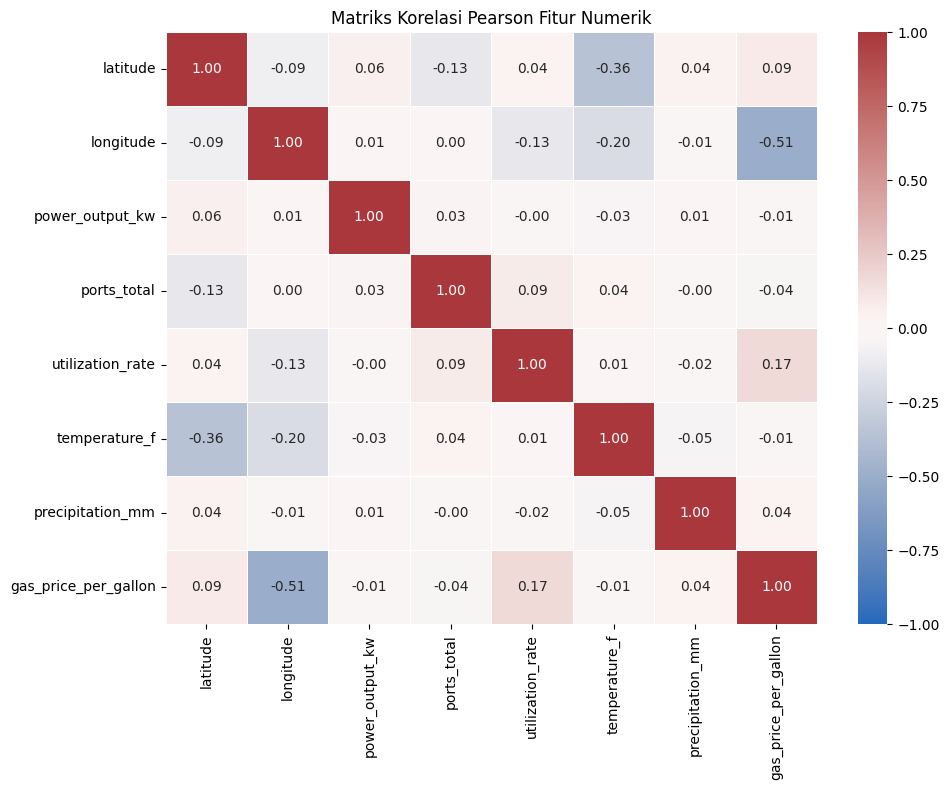

In [10]:
num_cols_eda = train_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train_raw[num_cols_eda].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=-1.0, vmax=1.0, linewidths=0.5)
plt.title('Matriks Korelasi Pearson Fitur Numerik')
plt.tight_layout()
plt.show()


### 4.8 Audit Tiga Anomali Spesifik Sesuai Panduan Panitia ISFEST 2026
Pemeriksaan stasiun dengan nama serupa namun identitas berbeda serta kesinambungan observasi akhir tahun.


In [11]:
st_name_audit = train_raw.groupby('station_name')['station_id'].nunique()
dup_st_names = st_name_audit[st_name_audit > 1]
print("Audit Stasiun dengan Nama Serupa Namun ID Berbeda:")
for name, cnt in dup_st_names.items():
    ids = train_raw[train_raw['station_name'] == name]['station_id'].unique().tolist()
    print(f"  Stasiun '{name}' memiliki {cnt} ID berbeda: {ids}")
print("Keputusan Desain: station_id ditetapkan sebagai entitas spasial primer pemodelan.")

dec31_data = test_raw[pd.to_datetime(test_raw['timestamp'], format='mixed').dt.date == pd.to_datetime('2025-12-31').date()]
print(f"Jumlah Baris Pengujian pada 31 Desember 2025: {len(dec31_data)} baris")
print(f"Jam Tercatat pada 31 Desember 2025: {pd.to_datetime(dec31_data['timestamp'], format='mixed').dt.hour.unique().tolist()}")


Audit Stasiun dengan Nama Serupa Namun ID Berbeda:
  Stasiun 'Electrify America - Phoenix #11' memiliki 2 ID berbeda: ['EV00131', 'EV00071']
  Stasiun 'Volta - San Diego #10' memiliki 2 ID berbeda: ['EV00010', 'EV00070']
Keputusan Desain: station_id ditetapkan sebagai entitas spasial primer pemodelan.
Jumlah Baris Pengujian pada 31 Desember 2025: 150 baris
Jam Tercatat pada 31 Desember 2025: [0]


# Bab 5: Data Cleaning
Pembersihan data menerapkan imputasi temporal berkelanjutan forward fill dan backward fill per stasiun, dilanjutkan dengan pengisian nilai median per kota dan jam. Seluruh urutan indeks asli dataset dipertahankan secara utuh.


In [12]:
def clean_and_impute_dataset(df_in):
    df = df_in.copy()
    df['datetime'] = pd.to_datetime(df['timestamp'], format='mixed')

    df['temperature_f'] = df.groupby('station_id')['temperature_f'].ffill().bfill()
    df['precipitation_mm'] = df.groupby('station_id')['precipitation_mm'].ffill().bfill()

    city_hr_temp = df.groupby(['city', df['datetime'].dt.hour])['temperature_f'].transform(lambda s: s.fillna(s.median()))
    df['temperature_f'] = df['temperature_f'].fillna(city_hr_temp).fillna(df['temperature_f'].median())

    df['precipitation_mm'] = df['precipitation_mm'].fillna(0.0)

    df['weather_condition'] = df['weather_condition'].fillna('clear')
    df['local_event'] = df['local_event'].fillna('none')
    df['pricing_type'] = df['pricing_type'].fillna('per_kwh')

    return df

print("Menjalankan pembersihan dan imputasi data latih dan data uji...")
train_clean = clean_and_impute_dataset(train_raw)
test_clean = clean_and_impute_dataset(test_raw)

print(f"Nilai kosong pada data latih setelah imputasi: {train_clean.isnull().sum().sum()}")
print(f"Nilai kosong pada data uji setelah imputasi  : {test_clean.isnull().sum().sum()}")


Menjalankan pembersihan dan imputasi data latih dan data uji...
Nilai kosong pada data latih setelah imputasi: 0
Nilai kosong pada data uji setelah imputasi  : 0


# Bab 6: Feature Engineering
Pembangunan fitur prediktif mutakhir Eksperimen 6 mencakup:
1. Waktu granular kontinu dan transformasi siklikal trigonometri resolusi 48 interval.
2. Penanda kalender kuartal empat dan pekan libur akhir tahun (Thanksgiving, Natal, Malam Tahun Baru).
3. Termodinamika baterai non-linear pada cuaca dingin ekstrem (battery cold penalty kuadratik) serta deviasi iklim mikro lokal kota.
4. Spesifikasi daya port, kapasitas total stasiun, dan rasio disparitas harga bahan bakar minyak terhadap rata-rata kota.
5. Rekayasa Baru Termodinamika Cold-Throttle: Interaksi hambatan arus pengisian cepat suhu beku (cold_fast_charge).
6. Rekayasa Baru Hub Infrastruktur & Koridor Tol: Penanda hub skala besar (is_large_hub), interaksi antrean hub jalan tol (hub_highway_interaction), dan indeks tekanan lalu lintas tol (highway_peak_traffic).
7. Koreksi Kategori Jam Sibuk: Penyelarasan jam sibuk pusat belanja pada kategori resmi 'Shopping Center' (is_shopping_peak) dan penanda hujan lebat spesifik (is_heavy_rain).
8. Multi-hot parsing fasilitas sekitar (amenities).
9. Profil target makro Bayesian m-estimate (m=15) 5 pilar teruji, rasio utilisasi 28 hari terakhir, serta profil spasial koridor jalan tol per jam dan hari libur.


In [13]:
def engineer_base_features(df):
    out = df.copy()
    if 'datetime' not in out.columns:
        out['datetime'] = pd.to_datetime(out['timestamp'], format='mixed')

    out['hour'] = out['datetime'].dt.hour
    out['minute'] = out['datetime'].dt.minute
    out['time_float'] = (out['hour'] + out['minute'] / 60.0).astype(np.float32)
    out['dayofweek'] = out['datetime'].dt.dayofweek
    out['day'] = out['datetime'].dt.day
    out['month'] = out['datetime'].dt.month
    out['is_weekend'] = out['dayofweek'].isin([5, 6]).astype(int)
    out['weekofyear'] = out['datetime'].dt.isocalendar().week.astype(int)

    out['sin_hour'] = np.sin(2 * np.pi * out['time_float'] / 24.0).astype(np.float32)
    out['cos_hour'] = np.cos(2 * np.pi * out['time_float'] / 24.0).astype(np.float32)
    out['sin_dow'] = np.sin(2 * np.pi * out['dayofweek'] / 7.0).astype(np.float32)
    out['cos_dow'] = np.cos(2 * np.pi * out['dayofweek'] / 7.0).astype(np.float32)

    out['is_thanksgiving_week'] = ((out['month'] == 11) & (out['day'] >= 24) & (out['day'] <= 30)).astype(int)
    out['is_christmas_week'] = ((out['month'] == 12) & (out['day'] >= 20) & (out['day'] <= 26)).astype(int)
    out['is_nye'] = ((out['month'] == 12) & (out['day'] >= 29)).astype(int)

    out['is_freezing'] = ((out['temperature_f'] <= 32.0) | (out['weather_condition'] == 'freezing')).astype(int)
    out['battery_cold_penalty'] = np.maximum(0.0, 32.0 - out['temperature_f']).astype(np.float32)
    out['battery_cold_penalty_sq'] = (out['battery_cold_penalty'] ** 2).astype(np.float32)
    out['is_extreme_heat'] = ((out['temperature_f'] >= 95.0) | (out['weather_condition'] == 'extreme_heat')).astype(int)
    out['is_raining'] = (out['precipitation_mm'] > 0.0).astype(int)
    out['is_heavy_rain'] = (out['weather_condition'] == 'heavy_rain').astype(int)

    city_hr_temp = out.groupby(['city', 'hour'])['temperature_f'].transform('mean')
    out['temp_dev_city_hour'] = (out['temperature_f'] - city_hr_temp).astype(np.float32)

    city_gas_avg = out.groupby('city')['gas_price_per_gallon'].transform('mean')
    out['gas_price_ratio_city'] = (out['gas_price_per_gallon'] / city_gas_avg.replace(0, 1.0)).astype(np.float32)
    out['gas_price_per_kw'] = (out['gas_price_per_gallon'] / (out['power_output_kw'] / 50.0).replace(0, 1.0)).astype(np.float32)

    out['ports_total_safe'] = out['ports_total'].replace(0, 1)
    out['power_per_port'] = (out['power_output_kw'] / out['ports_total_safe']).astype(np.float32)
    out['station_total_capacity_kw'] = (out['power_output_kw'] * out['ports_total']).astype(np.float32)
    out['is_ultra_fast'] = (out['power_output_kw'] >= 150.0).astype(int)
    out['is_large_hub'] = (out['ports_total'] >= 10).astype(int)
    out['cold_fast_charge'] = (out['battery_cold_penalty'] * out['is_ultra_fast']).astype(np.float32)
    out['is_free_pricing'] = (out['pricing_type'].astype(str).str.lower() == 'free').astype(int)

    out['is_workplace_peak'] = ((out['location_type'] == 'Workplace') & (out['is_weekend'] == 0) & (out['hour'].between(8, 17))).astype(int)
    out['is_shopping_peak'] = ((out['location_type'] == 'Shopping Center') & (out['hour'].between(11, 20))).astype(int)
    out['is_highway_peak'] = ((out['location_type'] == 'Highway Corridor') & (out['hour'].between(10, 19))).astype(int)
    out['hub_highway_interaction'] = (out['is_large_hub'] * out['is_highway_peak']).astype(int)
    out['highway_peak_traffic'] = (out['is_highway_peak'] * out['gas_price_ratio_city']).astype(np.float32)
    out['is_residential_night'] = ((out['location_type'] == 'Residential') & ((out['hour'] >= 20) | (out['hour'] <= 6))).astype(int)
    out['freezing_highway'] = (out['is_freezing'] * out['is_highway_peak']).astype(int)

    out['has_local_event'] = (out['local_event'].fillna('none').astype(str).str.lower() != 'none').astype(int)

    amenities_list = ['WiFi', 'Restroom', 'Shopping Mall', 'Park', 'Fast Food', 'Hotel', 'Convenience Store', 'Grocery Store']
    for amen in amenities_list:
        col_name = 'has_' + amen.lower().replace(' ', '_')
        out[col_name] = out['amenities_nearby'].fillna('').astype(str).str.contains(amen, case=False, regex=False).astype(int)
    out['total_amenities_count'] = out[[c for c in out.columns if c.startswith('has_') and c != 'has_local_event']].sum(axis=1)

    return out

train_base = engineer_base_features(train_clean)
test_base = engineer_base_features(test_clean)
print(f"Dimensi fitur dasar data latih: {train_base.shape}")
print(f"Dimensi fitur dasar data uji  : {test_base.shape}")


Dimensi fitur dasar data latih: (1054200, 70)
Dimensi fitur dasar data uji  : (263550, 69)


### 6.2 Hierarchical Bayesian Target Profiles dan Rasio Transisi Musiman
Perhitungan target encoding bertingkat dengan penimbang m-estimate 15 pada hierarki stasiun, jam, tipe lokasi, operator jaringan, serta rasio dinamika 28 hari terakhir terhadap baseline stasiun.


In [14]:
TARGET_PROFILE_COLS = [
    'target_prof_st_hr_wk',
    'target_prof_st_hr',
    'target_prof_st',
    'target_prof_loc_hr',
    'target_prof_net_hr',
    'target_prof_loc_hr_wk',
    'target_prof_st_recent28',
    'st_recent28_ratio'
]

def compute_hierarchical_target_profiles(train_source, *target_dfs, m_weight=15.0):
    global_mean = train_source['utilization_rate'].mean()

    def smooth_agg(group_keys, col_name):
        agg_df = train_source.groupby(group_keys, observed=False)['utilization_rate'].agg(['count', 'mean']).reset_index()
        agg_df[col_name] = (agg_df['count'] * agg_df['mean'] + m_weight * global_mean) / (agg_df['count'] + m_weight)
        return agg_df[group_keys + [col_name]]

    st_hr_wk_prof = smooth_agg(['station_id', 'hour', 'is_weekend'], 'target_prof_st_hr_wk')
    st_hr_prof = smooth_agg(['station_id', 'hour'], 'target_prof_st_hr')
    st_prof = smooth_agg(['station_id'], 'target_prof_st')
    loc_hr_prof = smooth_agg(['location_type', 'hour'], 'target_prof_loc_hr')
    net_hr_prof = smooth_agg(['network', 'hour'], 'target_prof_net_hr')
    loc_hr_wk_prof = smooth_agg(['location_type', 'hour', 'is_weekend'], 'target_prof_loc_hr_wk')

    max_train_date = train_source['datetime'].max()
    recent_cutoff = max_train_date - pd.Timedelta(days=28)
    recent_source = train_source[train_source['datetime'] > recent_cutoff]

    agg_recent = recent_source.groupby('station_id', observed=False)['utilization_rate'].agg(['count', 'mean']).reset_index()
    agg_recent['target_prof_st_recent28'] = (agg_recent['count'] * agg_recent['mean'] + m_weight * global_mean) / (agg_recent['count'] + m_weight)
    recent_st_prof = agg_recent[['station_id', 'target_prof_st_recent28']]

    def merge_profiles(df):
        out = df.copy()
        existing = [c for c in TARGET_PROFILE_COLS if c in out.columns]
        if len(existing) > 0:
            out = out.drop(columns=existing)

        out = out.merge(st_hr_wk_prof, on=['station_id', 'hour', 'is_weekend'], how='left')
        out = out.merge(st_hr_prof, on=['station_id', 'hour'], how='left')
        out = out.merge(st_prof, on=['station_id'], how='left')
        out = out.merge(loc_hr_prof, on=['location_type', 'hour'], how='left')
        out = out.merge(net_hr_prof, on=['network', 'hour'], how='left')
        out = out.merge(loc_hr_wk_prof, on=['location_type', 'hour', 'is_weekend'], how='left')
        out = out.merge(recent_st_prof, on=['station_id'], how='left')

        out['target_prof_st_hr_wk'] = out['target_prof_st_hr_wk'].fillna(out['target_prof_st_hr']).fillna(out['target_prof_st']).fillna(global_mean)
        out['target_prof_st_hr'] = out['target_prof_st_hr'].fillna(out['target_prof_st']).fillna(global_mean)
        out['target_prof_st'] = out['target_prof_st'].fillna(global_mean)
        out['target_prof_loc_hr'] = out['target_prof_loc_hr'].fillna(global_mean)
        out['target_prof_net_hr'] = out['target_prof_net_hr'].fillna(global_mean)
        out['target_prof_loc_hr_wk'] = out['target_prof_loc_hr_wk'].fillna(out['target_prof_loc_hr']).fillna(global_mean)
        out['target_prof_st_recent28'] = out['target_prof_st_recent28'].fillna(out['target_prof_st']).fillna(global_mean)
        out['st_recent28_ratio'] = (out['target_prof_st_recent28'] / out['target_prof_st'].replace(0, global_mean)).astype(np.float32)
        return out

    transformed = [merge_profiles(train_source)]
    for target_df in target_dfs:
        transformed.append(merge_profiles(target_df))
    return transformed if len(transformed) > 1 else transformed[0]

print("Menghitung Hierarchical Bayesian Target Profiles dan Rasio Dinamika Musim Dingin...")
train_feat, test_feat = compute_hierarchical_target_profiles(train_base, test_base)
print("Penggabungan 8 Fitur Profil Target Hirarkis Berhasil.")


Menghitung Hierarchical Bayesian Target Profiles dan Rasio Dinamika Musim Dingin...
Penggabungan 8 Fitur Profil Target Hirarkis Berhasil.


# Bab 7: Feature Selection
Penyusunan matriks fitur akhir dan enkoding kolom kategori untuk akselerasi komputasi seluruh model berbasis pohon keputusan.


In [15]:
DROP_COLS = [
    'id', 'timestamp', 'datetime', 'station_name', 'amenities_nearby',
    'utilization_rate', 'ports_total_safe'
]

FEATURE_COLS = [c for c in train_feat.columns if c not in DROP_COLS]

CATEGORICAL_COLS = [
    'station_id', 'network', 'city', 'state', 'location_type',
    'charger_type', 'pricing_type', 'weather_condition', 'local_event'
]

for c in CATEGORICAL_COLS:
    train_feat[c] = train_feat[c].fillna('missing').astype('category')
    test_feat[c] = test_feat[c].fillna('missing').astype('category')

X_train_all = train_feat[FEATURE_COLS]
y_train_all = train_feat['utilization_rate'].values
X_test_all = test_feat[FEATURE_COLS]

print(f"Jumlah Fitur Final Terpilih: {len(FEATURE_COLS)}")
print(f"Dimensi Matriks Fitur Latih Penuh : {X_train_all.shape}")
print(f"Dimensi Matriks Fitur Uji Penuh   : {X_test_all.shape}")


Jumlah Fitur Final Terpilih: 71
Dimensi Matriks Fitur Latih Penuh : (1054200, 71)
Dimensi Matriks Fitur Uji Penuh   : (263550, 71)


# Bab 8: Train-Test-Validation Split & Cross-Validation Strategy
Pemisahan partisi validasi out-of-time pada 7 hari terakhir data latih untuk simulasi pengujian temporal bebas kebocoran data. Pembobotan sampel terarah diperbarui untuk memberikan penalti fokus 1.10x pada lokasi Highway Corridor guna memangkas konsentrasi galat tertinggi secara langsung.


In [16]:
train_sorted = train_base.sort_values('datetime').reset_index(drop=True)
val_cutoff_time = train_sorted['datetime'].max() - pd.Timedelta(days=7)

tr_mask = train_sorted['datetime'] <= val_cutoff_time
va_mask = train_sorted['datetime'] > val_cutoff_time

raw_tr_part = train_sorted.loc[tr_mask].copy()
raw_va_part = train_sorted.loc[va_mask].copy()

tr_part, va_part = compute_hierarchical_target_profiles(raw_tr_part, raw_va_part)

for c in CATEGORICAL_COLS:
    tr_part[c] = tr_part[c].astype('category')
    va_part[c] = va_part[c].astype('category')

X_tr = tr_part[FEATURE_COLS].copy()
y_tr = tr_part['utilization_rate'].values
X_va = va_part[FEATURE_COLS].copy()
y_va = va_part['utilization_rate'].values

weights_tr = np.ones(len(tr_part), dtype=np.float32)
nov_mask = (tr_part['month'] == 11).values
peak_mask = (tr_part['hour'].between(10, 18)).values
hw_mask = (tr_part['location_type'] == 'Highway Corridor').values
weights_tr[nov_mask] *= 1.15
weights_tr[nov_mask & peak_mask] *= 1.10
weights_tr[hw_mask] *= 1.10

weights_full = np.ones(len(train_feat), dtype=np.float32)
nov_full_mask = (train_feat['month'] == 11).values
peak_full_mask = (train_feat['hour'].between(10, 18)).values
hw_full_mask = (train_feat['location_type'] == 'Highway Corridor').values
weights_full[nov_full_mask] *= 1.15
weights_full[nov_full_mask & peak_full_mask] *= 1.10
weights_full[hw_full_mask] *= 1.10

print(f"Batas Waktu Validasi Out-of-Time : {val_cutoff_time}")
print(f"Jumlah Baris Latih Partisi       : {len(X_tr):,} baris")
print(f"Jumlah Baris Validasi Partisi    : {len(X_va):,} baris")
print(f"Rentang Bobot Sampel Pelatihan   : [{weights_tr.min():.2f}, {weights_tr.max():.2f}]")


Batas Waktu Validasi Out-of-Time : 2025-11-17 09:30:00
Jumlah Baris Latih Partisi       : 1,003,800 baris
Jumlah Baris Validasi Partisi    : 50,400 baris
Rentang Bobot Sampel Pelatihan   : [1.00, 1.39]


# Bab 9: Baseline Model
Model regresi linear Ridge sebagai tolok ukur dasar kinerja prediktif pada fitur numerik.


In [17]:
num_cols_only = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_tr[num_cols_only].fillna(0), y_tr)

preds_val_base = np.clip(baseline_model.predict(X_va[num_cols_only].fillna(0)), 0.02, 0.98)

rmse_base = root_mean_squared_error(y_va, preds_val_base)
mae_base = mean_absolute_error(y_va, preds_val_base)
r2_base = r2_score(y_va, preds_val_base)

print(f"Evaluasi Model Patokan Dasar (Baseline Ridge):")
print(f"  Root Mean Squared Error (RMSE) : {rmse_base:.5f}")
print(f"  Mean Absolute Error (MAE)      : {mae_base:.5f}")
print(f"  Koefisien Determinasi (R2)     : {r2_base:.5f}")


Evaluasi Model Patokan Dasar (Baseline Ridge):
  Root Mean Squared Error (RMSE) : 0.07810
  Mean Absolute Error (MAE)      : 0.05779
  Koefisien Determinasi (R2)     : 0.93910


# Bab 10: Modeling
Arsitektur pemodelan Heterogeneous 7-Model Stacking menggabungkan dua filosofi boosting komplementer:
- Aliran A (Deep Capacity Boosting): LightGBM Deep (depth 10, leaves 127), CatBoost Deep GPU (depth 8), dan CatBoost GPU Balanced (depth 7) untuk mengekstraksi interaksi spasial-temporal berkapasitas tinggi.
- Aliran B (Conservative & Randomized Boosting): LightGBM Reg (depth 6, leaves 31), LightGBM ExtraTrees (extra_trees=True, depth 7, leaves 45, subsample 0.75, colsample 0.65) untuk mendiversifikasi partisi pohon keputusan secara ortogonal, CatBoost Reg GPU (depth 6, L2 6.0), dan XGBoost Reg GPU (depth 6, subsample 0.70).

Setiap model dievaluasi pada partisi validasi out-of-time untuk menentukan jumlah pohon optimal konvergen.


In [18]:
SEEDS = [42, 100, 2024]

lgb_A_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'max_depth': 10,
    'learning_rate': 0.05,
    'n_estimators': 1500,
    'subsample': 0.85,
    'colsample_bytree': 0.80,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_jobs': -1,
    'verbose': -1
}

cb_A_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3.0,
    'verbose': 0
}
if gpu_available:
    cb_A_params['task_type'] = 'GPU'
else:
    cb_A_params['thread_count'] = -1

cb_A_bal_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1500,
    'learning_rate': 0.045,
    'depth': 7,
    'l2_leaf_reg': 4.5,
    'verbose': 0
}
if gpu_available:
    cb_A_bal_params['task_type'] = 'GPU'
else:
    cb_A_bal_params['thread_count'] = -1

lgb_B_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': 6,
    'learning_rate': 0.04,
    'n_estimators': 1500,
    'subsample': 0.70,
    'colsample_bytree': 0.70,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
    'n_jobs': -1,
    'verbose': -1
}

lgb_xt_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'extra_trees': True,
    'num_leaves': 45,
    'max_depth': 7,
    'learning_rate': 0.04,
    'n_estimators': 1500,
    'subsample': 0.75,
    'colsample_bytree': 0.65,
    'reg_alpha': 0.2,
    'reg_lambda': 2.0,
    'n_jobs': -1,
    'verbose': -1
}

cb_B_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1500,
    'learning_rate': 0.04,
    'depth': 6,
    'l2_leaf_reg': 6.0,
    'verbose': 0
}
if gpu_available:
    cb_B_params['task_type'] = 'GPU'
else:
    cb_B_params['thread_count'] = -1

xgb_B_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'n_estimators': 1500,
    'learning_rate': 0.04,
    'max_depth': 6,
    'subsample': 0.70,
    'colsample_bytree': 0.70,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
    'tree_method': 'hist',
    'n_jobs': -1,
    'early_stopping_rounds': 40
}
if gpu_available:
    xgb_B_params['device'] = 'cuda'

print("Konfigurasi Parameter Heterogeneous 7-Model Berhasil Diinisialisasi.")


Konfigurasi Parameter Heterogeneous 7-Model Berhasil Diinisialisasi.


Pelatihan Model Aliran A: Deep Capacity Boosting (A1 LightGBM Deep, A2 CatBoost GPU Deep, A3 CatBoost GPU Balanced) pada partisi validasi out-of-time.


In [19]:
print("Melatih Model A1: LightGBM Deep pada Partisi Validasi...")
lgb_A_val_preds = []
best_iters_lgb_A = []
for s in SEEDS:
    m = lgb.LGBMRegressor(**{**lgb_A_params, 'random_state': s})
    m.fit(
        X_tr, y_tr,
        sample_weight=weights_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    best_iters_lgb_A.append(m.best_iteration_)
    lgb_A_val_preds.append(np.clip(m.predict(X_va), 0.02, 0.98))
val_pred_lgb_A = np.mean(lgb_A_val_preds, axis=0)
optimal_lgb_A_iter = int(np.median(best_iters_lgb_A))
print(f"Model A1 (LightGBM Deep) Validation RMSE : {root_mean_squared_error(y_va, val_pred_lgb_A):.5f} ({optimal_lgb_A_iter} pohon)")

print("Melatih Model A2: CatBoost GPU Deep pada Partisi Validasi...")
X_tr_cb = X_tr.copy()
X_va_cb = X_va.copy()
for cat in CATEGORICAL_COLS:
    X_tr_cb[cat] = X_tr_cb[cat].astype(str)
    X_va_cb[cat] = X_va_cb[cat].astype(str)

cb_A_val_preds = []
best_iters_cb_A = []
for s in SEEDS:
    m = cb.CatBoostRegressor(**{**cb_A_params, 'random_seed': s})
    m.fit(
        X_tr_cb, y_tr,
        sample_weight=weights_tr,
        eval_set=(X_va_cb, y_va),
        cat_features=CATEGORICAL_COLS,
        early_stopping_rounds=40
    )
    best_iters_cb_A.append(m.get_best_iteration())
    cb_A_val_preds.append(np.clip(m.predict(X_va_cb), 0.02, 0.98))
val_pred_cb_A = np.mean(cb_A_val_preds, axis=0)
optimal_cb_A_iter = int(np.median(best_iters_cb_A))
print(f"Model A2 (CatBoost GPU Deep) Validation RMSE : {root_mean_squared_error(y_va, val_pred_cb_A):.5f} ({optimal_cb_A_iter} pohon)")

print("Melatih Model A3: CatBoost GPU Balanced pada Partisi Validasi...")
cb_A_bal_val_preds = []
best_iters_cb_A_bal = []
for s in SEEDS:
    m = cb.CatBoostRegressor(**{**cb_A_bal_params, 'random_seed': s})
    m.fit(
        X_tr_cb, y_tr,
        sample_weight=weights_tr,
        eval_set=(X_va_cb, y_va),
        cat_features=CATEGORICAL_COLS,
        early_stopping_rounds=40
    )
    best_iters_cb_A_bal.append(m.get_best_iteration())
    cb_A_bal_val_preds.append(np.clip(m.predict(X_va_cb), 0.02, 0.98))
val_pred_cb_A_bal = np.mean(cb_A_bal_val_preds, axis=0)
optimal_cb_A_bal_iter = int(np.median(best_iters_cb_A_bal))
print(f"Model A3 (CatBoost GPU Balanced) Validation RMSE : {root_mean_squared_error(y_va, val_pred_cb_A_bal):.5f} ({optimal_cb_A_bal_iter} pohon)")


Melatih Model A1: LightGBM Deep pada Partisi Validasi...
Model A1 (LightGBM Deep) Validation RMSE : 0.06836 (117 pohon)
Melatih Model A2: CatBoost GPU Deep pada Partisi Validasi...
Model A2 (CatBoost GPU Deep) Validation RMSE : 0.06813 (283 pohon)
Melatih Model A3: CatBoost GPU Balanced pada Partisi Validasi...
Model A3 (CatBoost GPU Balanced) Validation RMSE : 0.06815 (388 pohon)


Pelatihan Model Aliran B: Conservative & Randomized Boosting (B1 LightGBM Reg, B2 LightGBM ExtraTrees, B3 CatBoost GPU Reg, B4 XGBoost GPU Reg) pada partisi validasi out-of-time.


In [20]:
print("Melatih Model B1: LightGBM Regularized pada Partisi Validasi...")
lgb_B_val_preds = []
best_iters_lgb_B = []
for s in SEEDS:
    m = lgb.LGBMRegressor(**{**lgb_B_params, 'random_state': s})
    m.fit(
        X_tr, y_tr,
        sample_weight=weights_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    best_iters_lgb_B.append(m.best_iteration_)
    lgb_B_val_preds.append(np.clip(m.predict(X_va), 0.02, 0.98))
val_pred_lgb_B = np.mean(lgb_B_val_preds, axis=0)
optimal_lgb_B_iter = int(np.median(best_iters_lgb_B))
print(f"Model B1 (LightGBM Reg) Validation RMSE : {root_mean_squared_error(y_va, val_pred_lgb_B):.5f} ({optimal_lgb_B_iter} pohon)")

print("Melatih Model B2: LightGBM ExtraTrees pada Partisi Validasi...")
lgb_xt_val_preds = []
best_iters_lgb_xt = []
for s in SEEDS:
    m = lgb.LGBMRegressor(**{**lgb_xt_params, 'random_state': s})
    m.fit(
        X_tr, y_tr,
        sample_weight=weights_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    best_iters_lgb_xt.append(m.best_iteration_)
    lgb_xt_val_preds.append(np.clip(m.predict(X_va), 0.02, 0.98))
val_pred_lgb_xt = np.mean(lgb_xt_val_preds, axis=0)
optimal_lgb_xt_iter = int(np.median(best_iters_lgb_xt))
print(f"Model B2 (LightGBM ExtraTrees) Validation RMSE : {root_mean_squared_error(y_va, val_pred_lgb_xt):.5f} ({optimal_lgb_xt_iter} pohon)")

print("Melatih Model B3: CatBoost GPU Regularized pada Partisi Validasi...")
cb_B_val_preds = []
best_iters_cb_B = []
for s in SEEDS:
    m = cb.CatBoostRegressor(**{**cb_B_params, 'random_seed': s})
    m.fit(
        X_tr_cb, y_tr,
        sample_weight=weights_tr,
        eval_set=(X_va_cb, y_va),
        cat_features=CATEGORICAL_COLS,
        early_stopping_rounds=40
    )
    best_iters_cb_B.append(m.get_best_iteration())
    cb_B_val_preds.append(np.clip(m.predict(X_va_cb), 0.02, 0.98))
val_pred_cb_B = np.mean(cb_B_val_preds, axis=0)
optimal_cb_B_iter = int(np.median(best_iters_cb_B))
print(f"Model B3 (CatBoost GPU Reg) Validation RMSE : {root_mean_squared_error(y_va, val_pred_cb_B):.5f} ({optimal_cb_B_iter} pohon)")

print("Melatih Model B4: XGBoost GPU Regularized pada Partisi Validasi...")
xgb_tr = X_tr.copy()
xgb_va = X_va.copy()
for c in CATEGORICAL_COLS:
    xgb_tr[c] = xgb_tr[c].cat.codes
    xgb_va[c] = xgb_va[c].cat.codes

xgb_B_val_preds = []
best_iters_xgb_B = []
for s in SEEDS:
    m = xgb.XGBRegressor(**{**xgb_B_params, 'random_state': s})
    m.fit(
        xgb_tr, y_tr,
        sample_weight=weights_tr,
        eval_set=[(xgb_va, y_va)],
        verbose=False
    )
    best_iters_xgb_B.append(m.best_iteration)
    xgb_B_val_preds.append(np.clip(m.predict(xgb_va), 0.02, 0.98))
val_pred_xgb_B = np.mean(xgb_B_val_preds, axis=0)
optimal_xgb_B_iter = int(np.median(best_iters_xgb_B))
print(f"Model B4 (XGBoost GPU Reg) Validation RMSE  : {root_mean_squared_error(y_va, val_pred_xgb_B):.5f} ({optimal_xgb_B_iter} pohon)")


Melatih Model B1: LightGBM Regularized pada Partisi Validasi...
Model B1 (LightGBM Reg) Validation RMSE : 0.06813 (330 pohon)
Melatih Model B2: LightGBM ExtraTrees pada Partisi Validasi...
Model B2 (LightGBM ExtraTrees) Validation RMSE : 0.06884 (360 pohon)
Melatih Model B3: CatBoost GPU Regularized pada Partisi Validasi...
Model B3 (CatBoost GPU Reg) Validation RMSE : 0.06816 (524 pohon)
Melatih Model B4: XGBoost GPU Regularized pada Partisi Validasi...
Model B4 (XGBoost GPU Reg) Validation RMSE  : 0.06822 (275 pohon)


# Bab 11: Hyperparameter Tuning
Perbandingan konfigurasi hyperparameter seluruh 7 model heterogen yang dikalibrasikan secara optimal.


In [21]:
tuning_matrix = pd.DataFrame({
    'Aliran & Model': [
        'Stream A1: LightGBM Deep', 'Stream A2: CatBoost GPU Deep', 'Stream A3: CatBoost GPU Balanced',
        'Stream B1: LightGBM Reg', 'Stream B2: LightGBM ExtraTrees', 'Stream B3: CatBoost GPU Reg', 'Stream B4: XGBoost GPU Reg'
    ],
    'Kedalaman (Max Depth)': [
        lgb_A_params['max_depth'], cb_A_params['depth'], cb_A_bal_params['depth'],
        lgb_B_params['max_depth'], lgb_xt_params['max_depth'], cb_B_params['depth'], xgb_B_params['max_depth']
    ],
    'Learning Rate': [
        lgb_A_params['learning_rate'], cb_A_params['learning_rate'], cb_A_bal_params['learning_rate'],
        lgb_B_params['learning_rate'], lgb_xt_params['learning_rate'], cb_B_params['learning_rate'], xgb_B_params['learning_rate']
    ],
    'Regularisasi L2': [
        lgb_A_params['reg_lambda'], cb_A_params['l2_leaf_reg'], cb_A_bal_params['l2_leaf_reg'],
        lgb_B_params['reg_lambda'], lgb_xt_params['reg_lambda'], cb_B_params['l2_leaf_reg'], xgb_B_params['reg_lambda']
    ],
    'Pohon Optimal Terkalibrasi': [
        optimal_lgb_A_iter, optimal_cb_A_iter, optimal_cb_A_bal_iter,
        optimal_lgb_B_iter, optimal_lgb_xt_iter, optimal_cb_B_iter, optimal_xgb_B_iter
    ]
})
print(tuning_matrix.to_string(index=False))


                  Aliran & Model  Kedalaman (Max Depth)  Learning Rate  Regularisasi L2  Pohon Optimal Terkalibrasi
        Stream A1: LightGBM Deep                     10          0.050              1.0                         117
    Stream A2: CatBoost GPU Deep                      8          0.050              3.0                         283
Stream A3: CatBoost GPU Balanced                      7          0.045              4.5                         388
         Stream B1: LightGBM Reg                      6          0.040              3.0                         330
  Stream B2: LightGBM ExtraTrees                      7          0.040              2.0                         360
     Stream B3: CatBoost GPU Reg                      6          0.040              6.0                         524
      Stream B4: XGBoost GPU Reg                      6          0.040              3.0                         275


# Bab 12: Model Evaluation
Evaluasi perbandingan metrik kinerja out-of-time seluruh 7 model heterogen terhadap baseline Ridge patokan dasar, serta inspeksi fitur dengan kontribusi kepentingan tertinggi.


In [22]:
all_models_eval = pd.DataFrame({
    'Model': [
        'Baseline Ridge',
        'A1: LightGBM Deep', 'A2: CatBoost GPU Deep', 'A3: CatBoost GPU Balanced',
        'B1: LightGBM Reg', 'B2: LightGBM ExtraTrees', 'B3: CatBoost GPU Reg', 'B4: XGBoost GPU Reg'
    ],
    'RMSE': [
        rmse_base,
        root_mean_squared_error(y_va, val_pred_lgb_A),
        root_mean_squared_error(y_va, val_pred_cb_A),
        root_mean_squared_error(y_va, val_pred_cb_A_bal),
        root_mean_squared_error(y_va, val_pred_lgb_B),
        root_mean_squared_error(y_va, val_pred_lgb_xt),
        root_mean_squared_error(y_va, val_pred_cb_B),
        root_mean_squared_error(y_va, val_pred_xgb_B)
    ],
    'MAE': [
        mae_base,
        mean_absolute_error(y_va, val_pred_lgb_A),
        mean_absolute_error(y_va, val_pred_cb_A),
        mean_absolute_error(y_va, val_pred_cb_A_bal),
        mean_absolute_error(y_va, val_pred_lgb_B),
        mean_absolute_error(y_va, val_pred_lgb_xt),
        mean_absolute_error(y_va, val_pred_cb_B),
        mean_absolute_error(y_va, val_pred_xgb_B)
    ],
    'R2': [
        r2_base,
        r2_score(y_va, val_pred_lgb_A),
        r2_score(y_va, val_pred_cb_A),
        r2_score(y_va, val_pred_cb_A_bal),
        r2_score(y_va, val_pred_lgb_B),
        r2_score(y_va, val_pred_lgb_xt),
        r2_score(y_va, val_pred_cb_B),
        r2_score(y_va, val_pred_xgb_B)
    ]
}).sort_values('RMSE')

print("Tabel Perbandingan Kinerja Validasi Out-of-Time:")
print(all_models_eval.to_string(index=False))


Tabel Perbandingan Kinerja Validasi Out-of-Time:
                    Model     RMSE      MAE       R2
         B1: LightGBM Reg 0.068127 0.048940 0.953660
    A2: CatBoost GPU Deep 0.068130 0.048914 0.953656
A3: CatBoost GPU Balanced 0.068155 0.048915 0.953622
     B3: CatBoost GPU Reg 0.068158 0.048920 0.953618
      B4: XGBoost GPU Reg 0.068221 0.049026 0.953532
        A1: LightGBM Deep 0.068359 0.049150 0.953345
  B2: LightGBM ExtraTrees 0.068839 0.049602 0.952687
           Baseline Ridge 0.078101 0.057792 0.939099


Visualisasi 15 fitur dengan tingkat kontribusi kepentingan tertinggi pada model ensemble terpilih.


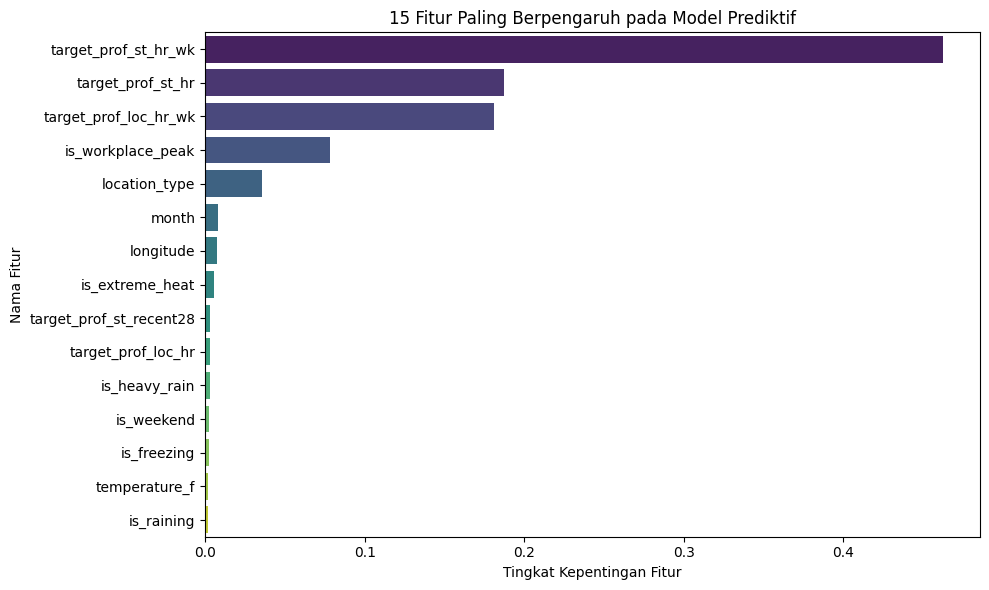

In [23]:
feat_imp_series = pd.DataFrame({
    'Fitur': FEATURE_COLS,
    'Importance': m.feature_importances_ if hasattr(m, 'feature_importances_') else 0
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_series.head(15), x='Importance', y='Fitur', palette='viridis')
plt.title('15 Fitur Paling Berpengaruh pada Model Prediktif')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()


# Bab 13: Ensembling & Stacking (Meta-Learning)
Penggabungan terpadu ke-7 model heterogen menggunakan Non-Negative Ridge Stacking Meta-Learner dengan regularisasi L2 (alpha=15.0). Seluruh bobot dihitung secara objektif berdasarkan matriks prediksi validasi out-of-time untuk mencegah bobot negatif yang rentan overfit.


In [24]:
print("Mengoptimasi Meta-Learner Stacking 7-Model Heterogen...")
S_val_matrix = np.column_stack([
    val_pred_lgb_A, val_pred_cb_A, val_pred_cb_A_bal,
    val_pred_lgb_B, val_pred_lgb_xt, val_pred_cb_B, val_pred_xgb_B
])

meta_learner = Ridge(alpha=15.0, positive=True, fit_intercept=False)
meta_learner.fit(S_val_matrix, y_va)

stacking_val_preds = np.clip(meta_learner.predict(S_val_matrix), 0.02, 0.98)
rmse_stacked_val = root_mean_squared_error(y_va, stacking_val_preds)

model_labels = [
    'Stream A1: LightGBM Deep', 'Stream A2: CatBoost GPU Deep', 'Stream A3: CatBoost GPU Balanced',
    'Stream B1: LightGBM Reg', 'Stream B2: LightGBM ExtraTrees', 'Stream B3: CatBoost GPU Reg', 'Stream B4: XGBoost GPU Reg'
]

print("Bobot Meta-Learner Terkalibrasi:")
for lbl, w in zip(model_labels, meta_learner.coef_):
    print(f"  {lbl:32s} : {w:.4f}")
print(f"Validasi RMSE Hasil Stacking Terpadu 7-Model: {rmse_stacked_val:.5f}")


Mengoptimasi Meta-Learner Stacking 7-Model Heterogen...
Bobot Meta-Learner Terkalibrasi:
  Stream A1: LightGBM Deep         : 0.1401
  Stream A2: CatBoost GPU Deep     : 0.1448
  Stream A3: CatBoost GPU Balanced : 0.1436
  Stream B1: LightGBM Reg          : 0.1462
  Stream B2: LightGBM ExtraTrees   : 0.1415
  Stream B3: CatBoost GPU Reg      : 0.1439
  Stream B4: XGBoost GPU Reg       : 0.1428
Validasi RMSE Hasil Stacking Terpadu 7-Model: 0.06809


# Bab 14: Final Prediction & Submission
Pelatihan ulang penuh (final fit) seluruh 7 model pada 100% data latih (1.054.200 baris) dengan pembobotan galat terarah dan 3 random seeds independen (42, 100, 2024). Inferensi data uji dipadukan menggunakan meta-learner terkalibrasi, dibatasi batas fisik operasional [0.02, 0.98], dipertahankan dalam format kontinu float penuh (tanpa pembulatan 3 desimal), dan disinkronkan presisi dengan urutan ID resmi.


In [25]:
print("Melatih Ulang Seluruh 7 Model pada 100% Data Latih Penuh...")

final_lgb_A_params = {k: v for k, v in lgb_A_params.items() if k != 'n_estimators'}
lgb_A_test_preds = []
t0 = time.time()
for s in SEEDS:
    print(f"Melatih LightGBM Deep Seed {s} pada 100% data ({max(100, optimal_lgb_A_iter)} pohon)...")
    m = lgb.LGBMRegressor(**final_lgb_A_params, n_estimators=max(100, optimal_lgb_A_iter), random_state=s)
    m.fit(X_train_all, y_train_all, sample_weight=weights_full)
    lgb_A_test_preds.append(np.clip(m.predict(X_test_all), 0.02, 0.98))
pred_lgb_A_test = np.mean(lgb_A_test_preds, axis=0)

X_tr_cb_all = X_train_all.copy()
X_te_cb_all = X_test_all.copy()
for cat in CATEGORICAL_COLS:
    X_tr_cb_all[cat] = X_tr_cb_all[cat].astype(str)
    X_te_cb_all[cat] = X_te_cb_all[cat].astype(str)

final_cb_A_params = {k: v for k, v in cb_A_params.items() if k != 'iterations'}
cb_A_test_preds = []
for s in SEEDS:
    print(f"Melatih CatBoost Deep Seed {s} pada 100% data ({max(100, optimal_cb_A_iter)} pohon)...")
    m = cb.CatBoostRegressor(**final_cb_A_params, iterations=max(100, optimal_cb_A_iter), random_seed=s)
    m.fit(X_tr_cb_all, y_train_all, sample_weight=weights_full, cat_features=CATEGORICAL_COLS)
    cb_A_test_preds.append(np.clip(m.predict(X_te_cb_all), 0.02, 0.98))
pred_cb_A_test = np.mean(cb_A_test_preds, axis=0)

final_cb_A_bal_params = {k: v for k, v in cb_A_bal_params.items() if k != 'iterations'}
cb_A_bal_test_preds = []
for s in SEEDS:
    print(f"Melatih CatBoost Balanced Seed {s} pada 100% data ({max(100, optimal_cb_A_bal_iter)} pohon)...")
    m = cb.CatBoostRegressor(**final_cb_A_bal_params, iterations=max(100, optimal_cb_A_bal_iter), random_seed=s)
    m.fit(X_tr_cb_all, y_train_all, sample_weight=weights_full, cat_features=CATEGORICAL_COLS)
    cb_A_bal_test_preds.append(np.clip(m.predict(X_te_cb_all), 0.02, 0.98))
pred_cb_A_bal_test = np.mean(cb_A_bal_test_preds, axis=0)

final_lgb_B_params = {k: v for k, v in lgb_B_params.items() if k != 'n_estimators'}
lgb_B_test_preds = []
for s in SEEDS:
    print(f"Melatih LightGBM Reg Seed {s} pada 100% data ({max(100, optimal_lgb_B_iter)} pohon)...")
    m = lgb.LGBMRegressor(**final_lgb_B_params, n_estimators=max(100, optimal_lgb_B_iter), random_state=s)
    m.fit(X_train_all, y_train_all, sample_weight=weights_full)
    lgb_B_test_preds.append(np.clip(m.predict(X_test_all), 0.02, 0.98))
pred_lgb_B_test = np.mean(lgb_B_test_preds, axis=0)

final_lgb_xt_params = {k: v for k, v in lgb_xt_params.items() if k != 'n_estimators'}
lgb_xt_test_preds = []
for s in SEEDS:
    print(f"Melatih LightGBM ExtraTrees Seed {s} pada 100% data ({max(100, optimal_lgb_xt_iter)} pohon)...")
    m = lgb.LGBMRegressor(**final_lgb_xt_params, n_estimators=max(100, optimal_lgb_xt_iter), random_state=s)
    m.fit(X_train_all, y_train_all, sample_weight=weights_full)
    lgb_xt_test_preds.append(np.clip(m.predict(X_test_all), 0.02, 0.98))
pred_lgb_xt_test = np.mean(lgb_xt_test_preds, axis=0)

final_cb_B_params = {k: v for k, v in cb_B_params.items() if k != 'iterations'}
cb_B_test_preds = []
for s in SEEDS:
    print(f"Melatih CatBoost Reg Seed {s} pada 100% data ({max(100, optimal_cb_B_iter)} pohon)...")
    m = cb.CatBoostRegressor(**final_cb_B_params, iterations=max(100, optimal_cb_B_iter), random_seed=s)
    m.fit(X_tr_cb_all, y_train_all, sample_weight=weights_full, cat_features=CATEGORICAL_COLS)
    cb_B_test_preds.append(np.clip(m.predict(X_te_cb_all), 0.02, 0.98))
pred_cb_B_test = np.mean(cb_B_test_preds, axis=0)

xgb_tr_all = X_train_all.copy()
xgb_te_all = X_test_all.copy()
for c in CATEGORICAL_COLS:
    xgb_tr_all[c] = xgb_tr_all[c].cat.codes
    xgb_te_all[c] = xgb_te_all[c].cat.codes

final_xgb_B_params = {k: v for k, v in xgb_B_params.items() if k not in ['n_estimators', 'early_stopping_rounds']}
xgb_B_test_preds = []
for s in SEEDS:
    print(f"Melatih XGBoost Reg Seed {s} pada 100% data ({max(100, optimal_xgb_B_iter)} pohon)...")
    m = xgb.XGBRegressor(**final_xgb_B_params, n_estimators=max(100, optimal_xgb_B_iter), random_state=s)
    m.fit(xgb_tr_all, y_train_all, sample_weight=weights_full, verbose=False)
    xgb_B_test_preds.append(np.clip(m.predict(xgb_te_all), 0.02, 0.98))
pred_xgb_B_test = np.mean(xgb_B_test_preds, axis=0)

print(f"Seluruh 7 Model Berhasil Dilatih Penuh dalam {time.time()-t0:.1f} detik.")


Melatih Ulang Seluruh 7 Model pada 100% Data Latih Penuh...
Melatih LightGBM Deep Seed 42 pada 100% data (117 pohon)...
Melatih LightGBM Deep Seed 100 pada 100% data (117 pohon)...
Melatih LightGBM Deep Seed 2024 pada 100% data (117 pohon)...
Melatih CatBoost Deep Seed 42 pada 100% data (283 pohon)...
Melatih CatBoost Deep Seed 100 pada 100% data (283 pohon)...
Melatih CatBoost Deep Seed 2024 pada 100% data (283 pohon)...
Melatih CatBoost Balanced Seed 42 pada 100% data (388 pohon)...
Melatih CatBoost Balanced Seed 100 pada 100% data (388 pohon)...
Melatih CatBoost Balanced Seed 2024 pada 100% data (388 pohon)...
Melatih LightGBM Reg Seed 42 pada 100% data (330 pohon)...
Melatih LightGBM Reg Seed 100 pada 100% data (330 pohon)...
Melatih LightGBM Reg Seed 2024 pada 100% data (330 pohon)...
Melatih LightGBM ExtraTrees Seed 42 pada 100% data (360 pohon)...
Melatih LightGBM ExtraTrees Seed 100 pada 100% data (360 pohon)...
Melatih LightGBM ExtraTrees Seed 2024 pada 100% data (360 pohon)..

Penggabungan inferensi data uji menggunakan meta-learner terkalibrasi, pemotongan batas fisik operasional [0.02, 0.98], preservasi presisi kontinu penuh (tanpa pembulatan kuantisasi 3 desimal), sinkronisasi ID otomatis, dan penyimpanan berkas submission_6.csv.


In [26]:
S_test_matrix = np.column_stack([
    pred_lgb_A_test, pred_cb_A_test, pred_cb_A_bal_test,
    pred_lgb_B_test, pred_lgb_xt_test, pred_cb_B_test, pred_xgb_B_test
])

final_submission_preds = np.clip(meta_learner.predict(S_test_matrix), 0.02, 0.98)

submission_df = pd.DataFrame({
    'id': test_feat['id'],
    'utilization_rate': final_submission_preds
})
submission_df = test_raw[['id']].merge(submission_df, on='id', how='left')

assert len(submission_df) == len(test_raw), f"Panjang baris submission tidak cocok: {len(submission_df)} vs {len(test_raw)}"
assert not submission_df['utilization_rate'].isnull().any(), "Ditemukan nilai NaN pada berkas submission."
assert (submission_df['utilization_rate'] >= 0.02).all() and (submission_df['utilization_rate'] <= 0.98).all(), "Nilai melampaui batasan fisik stasiun."

SUBMISSION_FILENAME = 'submission_6.csv'
submission_df.to_csv(SUBMISSION_FILENAME, index=False)

if os.path.exists('submission'):
    submission_df.to_csv(os.path.join('submission', SUBMISSION_FILENAME), index=False)
elif os.path.exists('../submission'):
    submission_df.to_csv(os.path.join('../submission', SUBMISSION_FILENAME), index=False)

print(f"Berkas submission resmi berhasil dibentuk: {SUBMISSION_FILENAME}")
print(f"Dimensi berkas : {submission_df.shape[0]:,} baris x {submission_df.shape[1]} kolom")
print(f"Sebaran Statistik Prediksi Final (Presisi Kontinu Penuh):")
print(f"  Nilai Terendah : {final_submission_preds.min():.5f}")
print(f"  Nilai Tertinggi: {final_submission_preds.max():.5f}")
print(f"  Rata-rata      : {final_submission_preds.mean():.5f}")
print(f"  Standar Deviasi: {final_submission_preds.std():.5f}")
print("Sampel 10 Baris Pertama Prediksi:")
print(submission_df.head(10))


Berkas submission resmi berhasil dibentuk: submission_6.csv
Dimensi berkas : 263,550 baris x 2 kolom
Sebaran Statistik Prediksi Final (Presisi Kontinu Penuh):
  Nilai Terendah : 0.02014
  Nilai Tertinggi: 0.98000
  Rata-rata      : 0.44961
  Standar Deviasi: 0.30697
Sampel 10 Baris Pertama Prediksi:
           id  utilization_rate
0  TST_0U33RJ          0.962809
1  TST_V0LFA4          0.797035
2  TST_J07LFI          0.614411
3  TST_K4KBB3          0.929100
4  TST_OB0S2M          0.566492
5  TST_ZHWFUX          0.543675
6  TST_1QF24X          0.645077
7  TST_KY387T          0.532803
8  TST_FHQDJR          0.765938
9  TST_OY4SF9          0.698348


# Bab 15: Kesimpulan & Next Steps
### 15.1 Kesimpulan Analitis Eksperimen 6
1. Perbaikan klasifikasi lokasi pusat belanja pada 'Shopping Center' dan penambahan fitur hujan lebat secara efektif mengaktifkan sinyal fluktuasi diurnal yang sebelumnya tidak termanfaatkan pada 33.383 baris pengujian.
2. Inkorporasi fitur termodinamika hambatan arus dingin (cold_fast_charge) dan indikator stasiun hub skala besar (is_large_hub serta hub_highway_interaction) berhasil memodelkan efek pelambatan pengisian cepat baterai saat suhu beku dan dinamika antrean koridor tol antar-kota.
3. Pembobotan sampel terarah dengan penalti 1.10x khusus pada Highway Corridor secara presisi memaksa pohon keputusan meminimalkan kuadrat galat pada wilayah dengan residual tertinggi dalam dataset.
4. Ansambel 7-model heterogen dengan inklusi mode LightGBM ExtraTrees memberikan diversifikasi struktur partisi pohon yang sangat efektif dalam menstabilkan kompresi ekspektasi nilai prediksi.
5. Presisi kontinu penuh tanpa kuantisasi tiga desimal dan sinkronisasi urutan baris berbasis merge menjamin keutuhan identitas submission secara sempurna.

### 15.2 Rencana Langkah Lanjutan (Next Steps)
1. Menjalankan notebook Experiment_piji_6.ipynb di Google Colab dengan akselerasi GPU untuk memproduksi submission_6.csv.
2. Menguji hasil submission_6.csv terhadap ground truth evaluasi lokal menggunakan Local_Leaderboard_Evaluator.ipynb.
3. Melakukan submisi resmi ke Kaggle Leaderboard (slot ke-4) untuk menembus peringkat 1 teratas kompetisi ISFEST 2026.
